In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import random
import torch.nn.functional as F
from torch.distributions import Categorical
import json
import os
import time
import matplotlib.pyplot as plt
import math

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
torch.cuda.manual_seed(42)
random.seed(42)

device

'cuda'

In [5]:
with open('/kaggle/input/shakespeare/input.txt', 'r') as f:
    data = f.read()

In [6]:
chars = sorted(list(set(data)))
data_size, vocab_size = len(data), len(chars)
print("----------------------------------------")
print("Data has {} characters, {} unique".format(data_size, vocab_size))
print("----------------------------------------")

# char to index and index to char maps
char_to_idx = { ch:i for i,ch in enumerate(chars) }
idx_to_char = { i:ch for i,ch in enumerate(chars) }

# convert data from chars to indices
data = list(data)
for i, ch in enumerate(data):
    data[i] = char_to_idx[ch]

# data tensor on device
data = torch.tensor(data).to(device)
data = torch.unsqueeze(data, dim=1)

----------------------------------------
Data has 1115394 characters, 65 unique
----------------------------------------


In [7]:
class CausalDepthWiseConv1d(nn.Module):
    def __init__(self, dim, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size
        self.net = nn.Sequential(
            nn.Conv1d(dim, dim, kernel_size = kernel_size, groups = dim),
        )
    def forward(self, x):
        x = x.permute(0, 2, 1) # b n d -> b d n
        x = F.pad(x, (self.kernel_size - 1, 0), value = 0.)
        x = self.net(x)
        return x.permute(0, 2, 1)

In [8]:
def get_batches(data, batch_size, seq_length):

    total_length = data.size(0)
    num_batches = (total_length - 1) // (batch_size * seq_length)

    data = data[:num_batches * batch_size * seq_length]

    data = data.view(batch_size, -1)
    
    for i in range(0, data.size(1) - seq_length, seq_length):
        x = data[:, i:i + seq_length]
        y = data[:, i + 1:i + seq_length + 1]
        yield x, y


In [9]:
class minLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, alpha=1.0):
        super().__init__()
        self.hidden_size = int(hidden_size * alpha)
        self.W_f = nn.Linear(input_size, hidden_size)
        self.W_i = nn.Linear(input_size, hidden_size)
        self.W_h = nn.Linear(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, input_size)
        # self.init_weights()

    def init_weights(self):
        stdv = 1.0 / math.sqrt(self.hidden_size)
        for weight in self.parameters():
            weight.data.uniform_(-stdv, stdv)

    def parallel_scan_log(self, log_coeffs, log_values):
        # log_coeffs: (batch_size, seq_len, input_size)
        # log_values: (batch_size, seq_len + 1, input_size)
        # print(f"Shape of log_coeffs: {log_coeffs.shape}")
        # print(f"Shape of log_values: {log_values.shape}")
        
        a_star = F.pad(torch.cumsum(log_coeffs, dim=1), (0, 0, 1, 0))
        
        log_h0_plus_b_star = torch.logcumsumexp(log_values - a_star, dim=1)
        log_h = a_star + log_h0_plus_b_star
        # print(f"Shape of log_h: {log_h.shape}")
        # print(f"Shape of log_h_sliced: {torch.exp(log_h)[:, 1:].shape}")
        return torch.exp(log_h)[:, 1:]


    def log_g(self, x):
        return torch.where(x >= 0, (F.relu(x)+0.5).log(), -F.softplus(-x))

    def g(self, x):
        return torch.where(x >= 0, x+0.5, torch.sigmoid(x))

    

    def forward(self, x, h_0):
                    
        # x: (batch_size, seq_len, input_size)
        # h_0: (batch_size, 1, hidden_size)

        diff = F.softplus(-self.W_f(x)) - F.softplus(-self.W_i(x))
        log_f = -F.softplus(diff)
        log_i = -F.softplus(-diff)
        log_h_0 = self.log_g(h_0)
        log_tilde_h = self.log_g(self.W_h(x))
        h = self.parallel_scan_log(log_f,
                                   torch.cat([log_h_0, log_i + log_tilde_h], dim=1))
        return self.fc(h)

    def sequential_forward(self, x_t, h_prev):
        # x_t: (batch_size, input_size)
        # h_prev: (batch_size, hidden_size)
        f_t = torch.sigmoid(self.W_f(x_t))
        i_t = torch.sigmoid(self.W_i(x_t))
        tilde_h_t = self.g(self.W_h(x_t))
        f_prime_t = f_t / (f_t + i_t)
        i_prime_t = i_t / (f_t + i_t)
        h_t = f_prime_t * h_prev + i_prime_t * tilde_h_t
        return self.fc(h_t)



In [10]:
input_size = 384
hidden_size = 128
seq_len = 512
batch_size = 64

dummy_model = minLSTM(input_size, hidden_size)
dummy_model.to(device)
x = torch.randn(batch_size, seq_len, input_size).to(device)
h_0 = torch.randn(batch_size, 1, hidden_size).to(device)

# output = dummy_model(x, h_0)
output2 = dummy_model.sequential_forward(x, h_0)

print(output2.shape, output2.shape)

torch.Size([64, 512, 384]) torch.Size([64, 512, 384])


In [15]:
input_size = 384
hidden_size = 128
seq_len = 512
batch_size = 64

dummy_model = minLSTM(input_size, hidden_size)
x = torch.randn(batch_size, seq_len, input_size).to(device)
h_0 = torch.randn(batch_size, 1, hidden_size).to(device)


num_runs = 100

total_time = 0
dummy_model.to(device)

with torch.inference_mode():
    for _ in range(num_runs):
        start_time = time.time()
        output = dummy_model(x, h_0)
        end_time = time.time()
        total_time += (end_time - start_time)

print(f"Shape of Output: {output.shape}")

total_time *= 1000
average_time = total_time / num_runs
print(f"Average time for forward pass over {num_runs} runs: {average_time:.2f} milli seconds")

Shape of Output: torch.Size([64, 512, 384])
Average time for forward pass over 100 runs: 3.47 milli seconds


In [16]:
class RNN2(nn.Module):
    def __init__(self, vocab_size, input_size, output_size, hidden_size, num_layers=1, dropout=0.0, alpha=1.0):
        super(RNN2, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = nn.Dropout(p=dropout)
        self.embedding = nn.Embedding(vocab_size, input_size)
        self.layers = nn.ModuleList([
            nn.Sequential(
                CausalDepthWiseConv1d(input_size if i == 0 else hidden_size, 4),
                nn.LayerNorm(input_size if i == 0 else hidden_size),
                minLSTM(input_size if i == 0 else hidden_size, hidden_size, alpha),
                nn.LayerNorm(hidden_size),
                nn.Sequential(
                    nn.Linear(hidden_size, hidden_size*4),
                    nn.GELU(),
                    nn.Linear(hidden_size*4, hidden_size)
                )
            )
            for i in range(num_layers)
        ])
        
        self.norm = nn.LayerNorm(hidden_size)
        self.decoder = nn.Linear(hidden_size, output_size)

    def init_hidden(self, batch_size):
        #return torch.zeros(batch_size, 1, self.hidden_size).to(device)
        return [torch.zeros(batch_size, 1, self.hidden_size).to(device) for _ in range(self.num_layers)]   # h_t

    def forward(self, input_seq):
        x = self.embedding(input_seq)  # (batch_size, seq_len, embedding_size)
        hidden_state = torch.zeros(x.shape[0], 1, self.hidden_size).to(device)
        
        for i, layer in enumerate(self.layers):
            conv1d, norm, lstm_layer, ff_norm, feed_forward = layer

            
            x_conv = conv1d(x) + x
              
            new_x = lstm_layer(norm(x_conv), hidden_state)
            
            hidden_state = new_x[:, -1:]  

            x = new_x + x_conv

            x_ff = feed_forward(ff_norm(x)) + x

            if i < len(self.layers) - 1:
                x = self.dropout(x_ff)
            else:
                x = x_ff


        x = self.norm(x)
        output_seq = self.decoder(x)        

        
        return output_seq #, new_hidden_states
        

In [17]:
for x, y in get_batches(data, 64, 512):
    break

print(x.shape)
dummy_model = RNN2(input_size=384, vocab_size=65, output_size=65, hidden_size=384, num_layers=3)
# dummy_hidden_state = dummy_model.init_hidden(64)
dummy_model.to(device)
with torch.inference_mode():
  output = dummy_model(x)
print(f"Shape of output_seq, hidden_state: {output.shape}")


torch.Size([64, 512])
Shape of output_seq, hidden_state: torch.Size([64, 512, 65])


In [18]:

def train(model, model_name, loss_fn, optimizer, epochs, device, train_data, test_data, save=False, save_path='/kaggle/working/training_info.json'):
    seq_len = 512       
    batch_size = 64   

    model.to(device)
    model.train()
    train_data = train_data.to(device)
    test_data = test_data.to(device)
    train_data_size = train_data.size(0)
    test_data_size = test_data.size(0)

    training_losses = []
    testing_losses = []

    # Start time for training
    start_time = time.time()

    print(f"Running on device: {device}\n")



    for i_epoch in tqdm(range(1, epochs + 1), desc="Training Epochs", unit="epoch"):
        # Training phase
        model.train()
        running_loss = 0
        # hidden_states = model.init_hidden(batch_size) 
        n = 0
    
        for input_seq, target_seq in get_batches(train_data, batch_size, seq_len):
            
            output = model(input_seq)
    
            loss = loss_fn(output.view(-1, vocab_size), target_seq.reshape(seq_len * batch_size))
            running_loss += loss.item()
            
    
            optimizer.zero_grad()
            # print(f"loss before back propagation: {loss}")
            loss.backward()
            # print(f"loss after back propagation: {loss}\n")
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
            optimizer.step()
    
            n += 1
    
        avg_train_loss = running_loss / n
        training_losses.append(avg_train_loss)
    
        # Testing phase
        model.eval()
        with torch.no_grad():
            test_running_loss = 0
            # test_hidden_states = model.init_hidden(batch_size)
            n_test = 0
    
            for test_input_seq, test_target_seq in get_batches(test_data, batch_size, seq_len):
    
                test_output = model(test_input_seq)
                test_loss = loss_fn(test_output.view(-1, vocab_size), test_target_seq.reshape(seq_len * batch_size))
                
                test_running_loss += test_loss.item()
    
                n_test += 1
    
            avg_test_loss = test_running_loss / n_test
            testing_losses.append(avg_test_loss)
            
            #if (i_epoch) % 25 == 0 or i_epoch == 1:
            print(f"Epoch: {i_epoch} \t Training Loss: {avg_train_loss:.4f} \t Testing Loss: {avg_test_loss:.4f}")
            
            # if avg_test_loss <= 1.56:
            #     break


    # End time for training
    end_time = time.time()
    
    training_time = end_time - start_time
    unit_training = ""
    unit_per_epoch = ""
    training_time_ = training_time
    if (training_time / 60) < 1:
        unit_training = "seconds"
    else:
        training_time_ = training_time / 60
        unit_training = "minutes"

    if ((training_time / 60) / epochs) < 1:
        training_time_per_epoch = training_time / epochs
        unit_per_epoch = "seconds"
    else:
        training_time_per_epoch = (training_time / 60) / epochs
        unit_per_epoch = "minutes"
        

    # Save training information
    training_info = {
        "model_name": model_name,
        "epochs": epochs,
        "device": str(device),
        "time_taken": f"{round(training_time_, 2)} {unit_training}",
        "time_taken_per_epoch": f"{round(training_time_per_epoch, 2)} {unit_per_epoch}",
        "last_train_loss": round(avg_train_loss, 4),
        "last_test_loss": round(avg_test_loss, 4)
    }

    if save:
        if os.path.exists(save_path):
            with open(save_path, 'r') as f:
                existing_data = json.load(f)
        else:
            existing_data = {}

        existing_data[f"model_{len(existing_data) + 1}"] = training_info

        with open(save_path, 'w') as f:
            json.dump(existing_data, f, indent=4)

        saved_model_path = f"/kaggle/working/{model_name}.pth"
        torch.save(model.state_dict(), saved_model_path)

    print("\nTraining Completed")
    print(f"Epochs Run: {training_info['epochs']}")
    print(f"Device Used: {training_info['device']}")
    print(f"Time Taken: {training_info['time_taken']}")
    print(f"Time Taken per Epoch: {training_info['time_taken_per_epoch']}")
    print(f"Last Training Loss: {training_info['last_train_loss']:.4f}")
    print(f"Last Testing Loss: {training_info['last_test_loss']:.4f}")

    return training_losses, testing_losses


In [19]:
lr = 0.001
epochs = 15
embedding_size = 384
alpha = 2
hidden_size = embedding_size
dropout = 0.2
num_layers = 3

model_name = "minLSTM"
training_split = 0.9
train_data, test_data = data[:int(len(data) * training_split)], data[int(len(data) * training_split):]


model = RNN2(input_size=embedding_size, vocab_size=vocab_size, output_size=vocab_size, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout, alpha=alpha)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

In [20]:
training_losses, testing_losses = train(model=model,
                                        model_name=model_name,
                                        loss_fn=loss_fn,
                                        optimizer=optimizer,
                                        train_data=train_data,
                                        test_data=test_data,
                                        device=device,
                                        epochs=epochs,
                                        save=False) 

Running on device: cuda



Training Epochs:   0%|          | 0/15 [00:00<?, ?epoch/s]

Epoch: 1 	 Training Loss: 2.6785 	 Testing Loss: 2.2001
Epoch: 2 	 Training Loss: 2.0841 	 Testing Loss: 2.0087
Epoch: 3 	 Training Loss: 1.8745 	 Testing Loss: 1.9112
Epoch: 4 	 Training Loss: 1.7341 	 Testing Loss: 1.8457
Epoch: 5 	 Training Loss: 1.6307 	 Testing Loss: 1.8015
Epoch: 6 	 Training Loss: 1.5544 	 Testing Loss: 1.7581
Epoch: 7 	 Training Loss: 1.4953 	 Testing Loss: 1.7189
Epoch: 8 	 Training Loss: 1.4501 	 Testing Loss: 1.7037
Epoch: 9 	 Training Loss: 1.4140 	 Testing Loss: 1.6545
Epoch: 10 	 Training Loss: 1.3861 	 Testing Loss: 1.6338
Epoch: 11 	 Training Loss: 1.3567 	 Testing Loss: 1.6094
Epoch: 12 	 Training Loss: 1.3346 	 Testing Loss: 1.5968
Epoch: 13 	 Training Loss: 1.3153 	 Testing Loss: 1.5866
Epoch: 14 	 Training Loss: 1.2987 	 Testing Loss: 1.5795
Epoch: 15 	 Training Loss: 1.2812 	 Testing Loss: 1.5760

Training Completed
Epochs Run: 15
Device Used: cuda
Time Taken: 1.78 minutes
Time Taken per Epoch: 7.11 seconds
Last Training Loss: 1.2812
Last Testing L

In [21]:
def plot_training_testing_losses(training_losses, testing_losses):
    plt.figure(figsize=(10, 6))
    
    plt.plot(range(1, len(training_losses)+1), training_losses, label="Training Loss", color="blue", linestyle="-")
    plt.plot(range(1, len(testing_losses)+1), testing_losses, label="Testing Loss", color="orange", linestyle="-")

    plt.title("Training and Testing Loss Over Epochs", fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Loss", fontsize=14)
    
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(loc="upper right", fontsize=12)
    
    min_train_loss = min(training_losses)
    min_train_epoch = training_losses.index(min_train_loss) + 1
    min_test_loss = min(testing_losses)
    min_test_epoch = testing_losses.index(min_test_loss) + 1
    
    plt.annotate(f'Min Training Loss: {min_train_loss:.4f}\n(Epoch: {min_train_epoch})', 
                 xy=(min_train_epoch, min_train_loss),
                 xytext=(min_train_epoch, min_train_loss + 0.1),
                 arrowprops=dict(facecolor='blue', shrink=0.05),
                 fontsize=10, color="blue")
    
    plt.annotate(f'Min Testing Loss: {min_test_loss:.4f}\n(Epoch: {min_test_epoch})', 
                 xy=(min_test_epoch, min_test_loss),
                 xytext=(min_test_epoch, min_test_loss + 0.1),
                 arrowprops=dict(facecolor='orange', shrink=0.05),
                 fontsize=10, color="orange")
    
    plt.show()


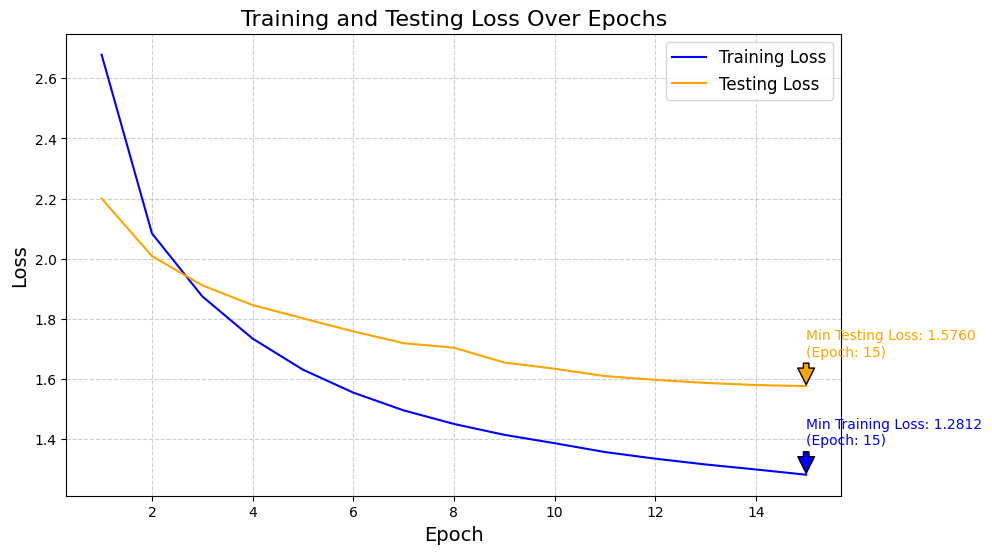

In [22]:
plot_training_testing_losses(training_losses, testing_losses)

In [26]:
from torch.utils.data import DataLoader, Dataset
class TextSamplerDataset(Dataset):
    def __init__(self, data, seq_len):
        super().__init__()
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return self.data.size(0) // self.seq_len

    def __getitem__(self, index):
        rand_start = torch.randint(0, self.data.size(0) - self.seq_len, (1,))
        full_seq = self.data[rand_start : rand_start + self.seq_len + 1].long()
        return full_seq.cuda()

train_dataset = TextSamplerDataset(train_data, 512)
train_loader = DataLoader(train_dataset, batch_size = 64)

In [27]:
def decode_token(token):
    return str(chr(max(32, token)))

def decode_tokens(tokens):
    return "".join(list(map(decode_token, tokens)))

def log(t, eps = 1e-20):
    return torch.log(t.clamp(min = eps))

def gumbel_noise(t):
    noise = torch.zeros_like(t).uniform_(0, 1)
    return -log(-log(noise))

def gumbel_sample(t, temperature = 1., dim = -1, keepdim = True):
    return ((t / max(temperature, 1e-10)) + gumbel_noise(t)).argmax(dim = dim, keepdim = keepdim)

def top_k(logits, thres = 0.9):
    k = math.ceil((1 - thres) * logits.shape[-1])
    val, ind = torch.topk(logits, k)
    probs = torch.full_like(logits, float('-inf'))
    probs.scatter_(-1, ind, val)
    return probs

def base_decoding(net, prompt, seq_len, temperature = 1., filter_thres = 0.9,):
    prompt_seq_len, out = prompt.shape[-1], prompt.clone()
    sample_num_times = max(0, seq_len - prompt_seq_len)

    prev_hiddens = None

    out = out.squeeze(2)

    for _ in range(sample_num_times):
        # print(out.squeeze(2).shape)
        logits = net(out)
        # print(logits.shape)
        logits = logits[:, -1]

        logits = top_k(logits, thres = filter_thres)
        sample = gumbel_sample(logits, temperature = temperature, dim = -1)
        # print(out.shape)
        # print(sample.shape)

        out = torch.cat((out, sample), dim = -1)

    return out[..., prompt_seq_len:]

In [28]:
import random
inp = random.choice(train_dataset)[:128]
inp = inp.cuda()
prime = decode_tokens(inp)
prompt = inp[None, ...]
sampled = base_decoding(model, prompt, 500)
simple_list = sampled.squeeze().tolist()
text = [idx_to_char[idx] for idx in simple_list]
text = ''.join(text)

In [29]:
print("----------------------------------------")
print(text)
print("----------------------------------------")

----------------------------------------
s ours by murder, to make him a king!
Edward thy son, which now is Prince of Wales,
For Edward my son, which was Prince of Wales;
This is a provish'd till as were subject.

LEONTES:
It's a put in the prince, and the compound
With covil to that tears are great die and week thanks
He has done to do no more too. Why, the seats with the grave
To that wont as thy help out of the fought; the
wind in thy head a prover hate to such a counter.

CORIOLANUS:
How cuts her.

MARIANA:
Well, what, hath duty so thy stir a compout,
Sir at or the could from thy cempast to heaven,
His count of his court.

COMINIUS:
Hath you a conjured he
----------------------------------------
